# 13: Search, scoring costs, and a practical demo

[Course home](../README.md) · [Part III chapters](../chapters/README.md#part-iii-inference-time-reasoning-and-planning) · Topics **42, 44–46, 48**

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bshivambharadwaj/Reinforcement-Learning-Course/blob/main/notebooks/13_budgeted_reasoning_search.ipynb)

**Created by Shivam Bharadwaj**

Restart the kernel and run all cells. Defaults run on CPU using generated data and a transparent
categorical arithmetic policy. This is not an LLM benchmark. Colab clones published main when
necessary; local runs need the complete repository and its core requirements.

**Task contract:** left-to-right addition, three proposed intermediate sums, frozen error
probabilities, one unit per proposal, and a declared scorer-query cost. Independent final
evaluation is outside the inference allowance and cannot guide search. Count abstentions as
failures. The code is MIT; educational text and outputs use CC BY 4.0.

In [1]:
from pathlib import Path
import sys
import subprocess

# Local: open from the full checkout. Colab: clone the published course once.
roots = [Path.cwd(), Path.cwd().parent, Path('/content/rl-course')]
root = next((p for p in roots if (p / 'rl_course' / 'inference.py').exists()), None)
if root is None and 'google.colab' in sys.modules:
    root = Path('/content/rl-course')
    if not root.exists():
        subprocess.run(['git', 'clone', '--depth', '1',
                        'https://github.com/bshivambharadwaj/Reinforcement-Learning-Course.git', str(root)], check=True)
if root is None or not (root / 'rl_course' / 'inference.py').exists():
    raise RuntimeError('Use the complete updated repository. Colab uses published main; push Part III before opening its badge.')
sys.path.insert(0, str(root))

import math
import random
from statistics import mean
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from rl_course.inference import (Task, Trace, FrozenPolicy, METHODS, infer, evaluate,
                                 process_score, make_tasks, benchmark, distill)

plt.rcParams.update({'figure.figsize': (9, 4), 'figure.facecolor': '#f5f1e8',
                     'axes.facecolor': '#ffffff', 'text.color': '#292332',
                     'axes.labelcolor': '#292332', 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})
COLORS = ['#292332', '#af824a', '#768165', '#87708c', '#95654f']
policy = FrozenPolicy()
tasks = make_tasks(100, seed=2026)
seeds = (7, 19, 41)
budgets = (6, 12, 24, 48)

def show_rows(rows):
    lines = ['| Method | Budget | Answer | Process | Oracle candidates | Used units | Completion |',
             '|---|---:|---:|---:|---:|---:|---:|']
    keys = list(dict.fromkeys((r['method'], r['budget']) for r in rows))
    for method, budget in keys:
        group = [r for r in rows if r['method'] == method and r['budget'] == budget]
        avg = lambda key: mean(r[key] for r in group)
        lines.append(f"| {method} | {budget} | {avg('answer_correct'):.1%} | {avg('process_valid'):.1%} | "
                     f"{avg('candidate_oracle_success'):.1%} | {avg('spent'):.1f} | {avg('completed'):.1%} |")
    display(Markdown('\n'.join(lines)))

def plot_rows(rows, metric='answer_correct', xmetric='budget'):
    fig, ax = plt.subplots()
    for color, method in zip(COLORS, dict.fromkeys(r['method'] for r in rows)):
        groups = [[r for r in rows if r['method'] == method and r['budget'] == b]
                  for b in sorted(set(r['budget'] for r in rows))]
        x = [mean(r[xmetric] for r in group) for group in groups]
        y = [mean(r[metric] for r in group) for group in groups]
        ax.plot(x, y, marker='o', label=method, color=color)
        # Show every generation-seed aggregate; these are not training seeds.
        for xx, group in zip(x, groups):
            ax.scatter([xx] * len(group), [r[metric] for r in group], color=color, alpha=.35, s=18)
    ax.set(xlabel='Budget cap' if xmetric == 'budget' else 'Mean work units actually used',
           ylabel=metric.replace('_', ' '), ylim=(-.03, 1.03))
    ax.legend(fontsize=8); fig.tight_layout(); plt.show()

print('Python', sys.version.split()[0], '| NumPy', np.__version__)
print('Frozen offsets (-1, 0, +1):', policy.probabilities)
print('100 unique tasks, 3 generation seeds; no model downloads or parameter updates during inference.')

Python 3.12.4 | NumPy 2.5.3
Frozen offsets (-1, 0, +1): (0.1, 0.4, 0.5)
100 unique tasks, 3 generation seeds; no model downloads or parameter updates during inference.


## 1. Inspect an expansion trace

Sampled beam search keeps a bounded set at each depth. Best-first uses a scored priority
queue, preferring deeper prefixes on score ties. Both charge generated duplicate
children and score queries. Neither implements MCTS.

In [2]:
result = infer(tasks[0], method='best_first', budget=24, seed=7)
print('Operands:', tasks[0].operands)
for event in result.events:
    print(event)
print('Selected:', result.selected)
print('Independent metrics:', result.metrics())
assert result.ledger.spent <= 24
assert result.selected is None or len(result.selected.values) == tasks[0].depth

Operands: (13, 20, 26, 26)
{'prefix': [], 'values': [33], 'score': 1.0, 'spent': 2}
{'prefix': [], 'values': [33], 'score': 1.0, 'spent': 4}
{'prefix': [33], 'values': [33, 60], 'score': 0.5, 'spent': 6}
{'prefix': [33], 'values': [33, 58], 'score': 0.5, 'spent': 8}
{'prefix': [33], 'values': [33, 60], 'score': 0.5, 'spent': 10}
{'prefix': [33], 'values': [33, 59], 'score': 1.0, 'spent': 12}
{'prefix': [33, 59], 'values': [33, 59, 84], 'score': 0.6666666666666666, 'spent': 14}
{'prefix': [33, 59], 'values': [33, 59, 86], 'score': 0.6666666666666666, 'spent': 16}
{'prefix': [33, 60], 'values': [33, 60, 85], 'score': 0.3333333333333333, 'spent': 18}
{'prefix': [33, 60], 'values': [33, 60, 86], 'score': 0.6666666666666666, 'spent': 20}
{'prefix': [33, 58], 'values': [33, 58, 83], 'score': 0.3333333333333333, 'spent': 22}
{'prefix': [33, 58], 'values': [33, 58, 83], 'score': 0.3333333333333333, 'spent': 24}
Selected: Trace(values=(33, 59, 84), log_probability=-4.135166556742355)
Independen

## 2. Compare all five strategies

The budget can run out before a tree method reaches a complete leaf. Those runs abstain
and count as failures. A fixed beam can also finish its entire configured tree before
spending a larger cap. Best-first has a finite sampled tree here too.

| Method | Budget | Answer | Process | Oracle candidates | Used units | Completion |
|---|---:|---:|---:|---:|---:|---:|
| single | 6 | 22.7% | 8.3% | 22.7% | 3.0 | 100.0% |
| self_consistency | 6 | 22.7% | 8.3% | 37.0% | 6.0 | 100.0% |
| best_of_n | 6 | 22.7% | 8.3% | 22.7% | 4.0 | 100.0% |
| beam | 6 | 0.0% | 0.0% | 0.0% | 6.0 | 0.0% |
| best_first | 6 | 0.0% | 0.0% | 0.0% | 6.0 | 0.0% |
| single | 12 | 22.7% | 8.3% | 22.7% | 3.0 | 100.0% |
| self_consistency | 12 | 18.3% | 5.7% | 56.7% | 12.0 | 100.0% |
| best_of_n | 12 | 23.3% | 17.3% | 49.0% | 12.0 | 100.0% |
| beam | 12 | 0.0% | 0.0% | 0.0% | 12.0 | 0.0% |
| best_first | 12 | 30.7% | 24.0% | 38.3% | 12.0 | 92.7% |
| single | 24 | 22.7% | 8.3% | 22.7% | 3.0 | 100.0% |
| self_consistency | 24 | 12.3% | 5.3% | 81.3% | 24.0 | 100.0% |
| best_of_n | 24 | 34.7% | 31.7% | 71.7% | 24.0 | 100.0% |
| beam | 24 | 35.3% | 32.7% | 63.0% | 20.0 | 100.0% |
| best_first | 24 | 33.7% | 29.3% | 66.3% | 24.0 | 100.0% |
| single | 48 | 22.7% | 8.3% | 22.7% | 3.0 | 100.0% |
| self_consistency | 48 | 9.0% | 3.0% | 96.3% | 48.0 | 100.0% |
| best_of_n | 48 | 53.3% | 52.7% | 92.0% | 48.0 | 100.0% |
| beam | 48 | 35.3% | 32.7% | 63.0% | 20.0 | 100.0% |
| best_first | 48 | 33.7% | 29.3% | 71.0% | 28.0 | 100.0% |

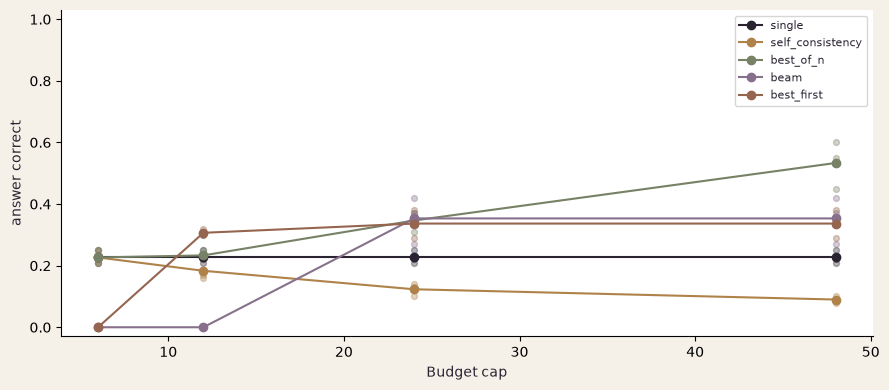

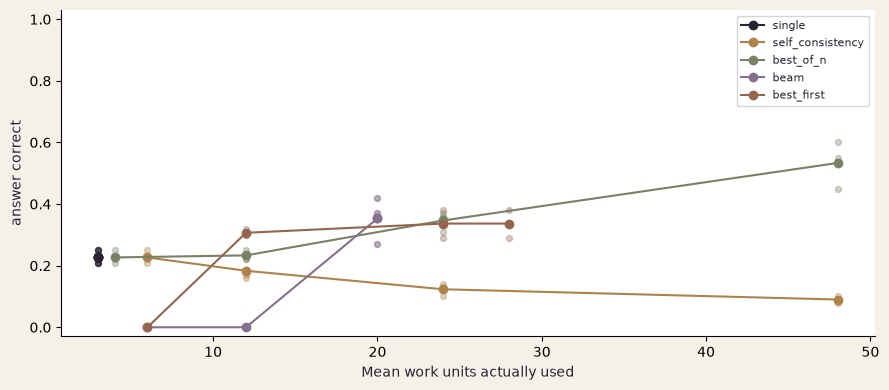

In [3]:
rows = benchmark(tasks, budgets=budgets, seeds=seeds)
show_rows(rows)
plot_rows(rows)
plot_rows(rows, xmetric='spent')
for row in rows:
    assert row['spent'] <= row['budget']
    assert row['answer_correct'] <= row['candidate_oracle_success'] + 1e-12

## 3. Scoring is not free

Raise the score-query cost from one to three. Tasks, proposal probabilities, and maximum
allowances stay fixed. A whole-trace query and a prefix query each count as one query;
this is an explicit abstraction, not measured equal hardware work.

| Method | Budget | Answer | Process | Oracle candidates | Used units | Completion |
|---|---:|---:|---:|---:|---:|---:|
| single | 24 | 22.7% | 8.3% | 22.7% | 3.0 | 100.0% |
| self_consistency | 24 | 12.3% | 5.3% | 81.3% | 24.0 | 100.0% |
| best_of_n | 24 | 27.7% | 22.7% | 56.7% | 24.0 | 100.0% |
| beam | 24 | 0.0% | 0.0% | 0.0% | 24.0 | 0.0% |
| best_first | 24 | 30.7% | 24.0% | 38.3% | 24.0 | 92.7% |
| single | 48 | 22.7% | 8.3% | 22.7% | 3.0 | 100.0% |
| self_consistency | 48 | 9.0% | 3.0% | 96.3% | 48.0 | 100.0% |
| best_of_n | 48 | 42.7% | 41.3% | 81.3% | 48.0 | 100.0% |
| beam | 48 | 35.3% | 32.7% | 63.0% | 40.0 | 100.0% |
| best_first | 48 | 33.7% | 29.3% | 66.3% | 48.0 | 100.0% |

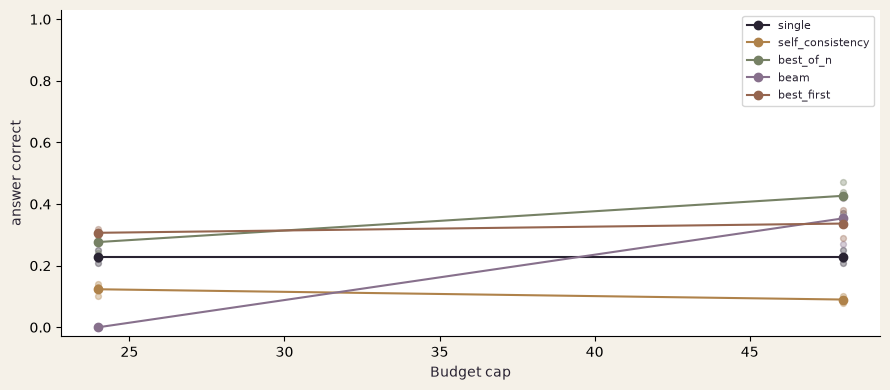

At depth 3 and cap 24: best-of-N candidates = 4


In [4]:
expensive = benchmark(tasks, budgets=(24,48), seeds=seeds, score_cost=3)
show_rows(expensive)
plot_rows(expensive)
print('At depth 3 and cap 24: best-of-N candidates =', 24//(3+3))

## 4. Scorer failure under search

Predict which prefixes a scorer rewarding +1 errors will expand. Then compare selected
correctness, valid process, and oracle candidate opportunity. Search can work exactly
as coded while optimizing the wrong target.

| Method | Budget | Answer | Process | Oracle candidates | Used units | Completion |
|---|---:|---:|---:|---:|---:|---:|
| single | 24 | 22.7% | 8.3% | 22.7% | 3.0 | 100.0% |
| self_consistency | 24 | 12.3% | 5.3% | 81.3% | 24.0 | 100.0% |
| best_of_n | 24 | 0.7% | 0.0% | 71.7% | 24.0 | 100.0% |
| beam | 24 | 0.7% | 0.0% | 30.3% | 20.0 | 100.0% |
| best_first | 24 | 2.0% | 0.0% | 53.7% | 24.0 | 100.0% |
| single | 48 | 22.7% | 8.3% | 22.7% | 3.0 | 100.0% |
| self_consistency | 48 | 9.0% | 3.0% | 96.3% | 48.0 | 100.0% |
| best_of_n | 48 | 0.0% | 0.0% | 92.0% | 48.0 | 100.0% |
| beam | 48 | 0.7% | 0.0% | 30.3% | 20.0 | 100.0% |
| best_first | 48 | 1.7% | 0.0% | 71.3% | 28.0 | 100.0% |

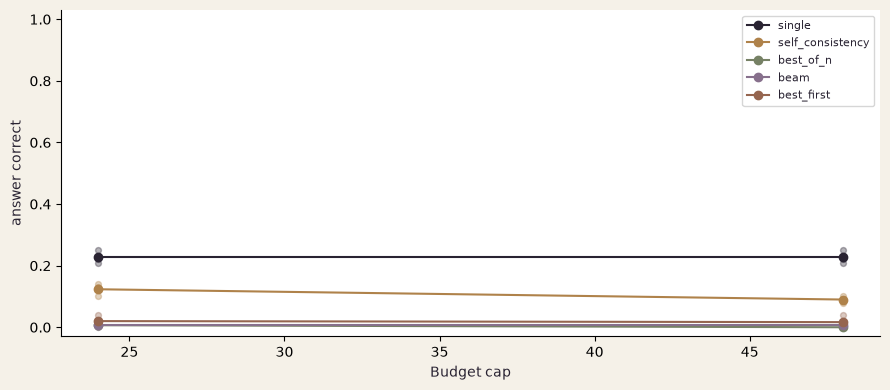

Search did not call the independent evaluator.


In [5]:
misleading = benchmark(tasks, budgets=(24,48), seeds=seeds, scorer='misleading')
show_rows(misleading)
plot_rows(misleading)
# Evaluator truth is not available to infer(): an executable leakage check.
from unittest.mock import patch
with patch('rl_course.inference.evaluate', side_effect=AssertionError('Truth leaked into search')):
    for method in METHODS:
        infer(tasks[0], method=method, budget=24)
print('Search did not call the independent evaluator.')

## 5. Generate the interactive demo

The output is a standalone HTML report with scorer, budget, and trace selectors. It
filters recorded results in the browser; it does not run a language model or make
network requests. The companion JSON retains generation-seed aggregates and example
expansion logs.

In [6]:
import tempfile
from rl_course.inference_demo import build_report, report_html
output_dir = Path(tempfile.mkdtemp(prefix='rl-inference-demo-'))
report = build_report(count=100)
html_path = output_dir / 'demo.html'
html_path.write_text(report_html(report), encoding='utf-8')
print('Open this HTML in a browser:', html_path)
print('A recorded version is also supplied in demos/inference-time/.')

Open this HTML in a browser: /tmp/rl-inference-demo-x2pw3mk7/demo.html
A recorded version is also supplied in demos/inference-time/.


## 6. Exercises

1. Derive the full sampled-tree cost for beam width 2, branching 2, depth 3, and score cost 1.
2. Increase width to 4 while retaining a cap of 24. Explain any incomplete runs.
3. Add an early-stopping rule using only a declared scorer, then measure actual cost and correctness.
4. Design a prefix-state merge and explain which process-history information must survive.

<details><summary>Answers and investigation guidance</summary>

1. Ten proposals and ten score queries, totaling 20. The fixed beam cannot use every larger allowance.
2. Wider early layers consume budget before reaching leaves. Do not drop abstentions from the denominator.
3. A score threshold is not a truth guarantee. Keep the independent evaluator inaccessible to search.
4. Equal current sums are insufficient if earlier process validity or context affects the objective or continuation.

</details>

Read [Tree of Thoughts](https://arxiv.org/abs/2305.10601) and
[Part III exercises](../chapters/PART_III_EXERCISES.md).